Data Loading and Merging

The first step is to combine the three datasets and "tag" them with their respective effective widths Weff


In [ ]:
import pandas as pd
import numpy as np

# Load the three datasets
# Note: Based on the file structure, we skip the first 2 rows of metadata
files = {
    40: "Grain2nm_lg16nm_weff40_vth_ion_ioff_simulated.csv",
    52: "Grain2nm_lg16nm_weff52_vth_ion_ioff_simulated.csv",
    60: "Grain2nm_lg16nm_weff60_vth_ion_ioff_simulated.csv"
}

dfs = []
for weff, file in files.items():
    # Reading CSV with header at row 2 (index 2)
    temp_df = pd.read_csv(file, header=2)
    # Remove unnamed or empty columns if present
    temp_df = temp_df.loc[:, ~temp_df.columns.str.contains('^Unnamed')]
    # Add the Weff column as a feature
    temp_df['Weff'] = weff
    dfs.append(temp_df)

# Merge all into one master dataframe
master_df = pd.concat(dfs, ignore_index=True)

# Data Cleaning: Convert OnCurrent/OnOffRatio to numeric (handling potential string types)
master_df['OnCurrent'] = pd.to_numeric(master_df['OnCurrent'], errors='coerce')
master_df['OffCurrent'] = pd.to_numeric(master_df['OffCurrent'], errors='coerce')

# Drop any NaN rows that might have occurred during conversion
master_df.dropna(inplace=True)

print(f"Master dataset created with {len(master_df)} samples.")
print(master_df.head())

Master dataset created with 598 samples.
   seed       Vth    OffCurrent  OnCurrent  OnOffRatio  Weff
0     1  0.397757  8.328400e-13   0.000024  28717000.0    40
1     2  0.383401  1.317970e-12   0.000024  18188700.0    40
2     3  0.385284  1.381080e-12   0.000024  17230100.0    40
3     4  0.392774  9.104920e-13   0.000024  26313700.0    40
4     5  0.378300  1.599710e-12   0.000024  15026500.0    40


Preprocessing and Feature Scaling

We use log-scaling for the currents to handle the wide range of magnitudes ($10^{-12}$ to $10^{-5}$)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare Features
# We need 'seed' as an integer for the Embedding layer (must start at 0)
master_df['seed_idx'] = master_df['seed'].astype(int) - 1
num_seeds = master_df['seed'].nunique()

# 2. Log transformation for currents
master_df['log_Ioff'] = np.log10(master_df['OffCurrent'])
master_df['log_Ion'] = np.log10(master_df['OnCurrent'])

# 3. Define Inputs and Targets
# X1: Numerical feature (Weff), X2: Categorical feature (Seed)
X_weff = master_df[['Weff']].values
X_seed = master_df['seed_idx'].values
y = master_df[['Vth', 'log_Ioff', 'log_Ion']].values

# 4. Split data (using indices to keep X_weff and X_seed aligned)
indices = np.arange(len(master_df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# 5. Scale the numerical input (Weff) and the targets
scaler_weff = StandardScaler()
scaler_y = StandardScaler()

X_weff_train = scaler_weff.fit_transform(X_weff[train_idx])
X_weff_test = scaler_weff.transform(X_weff[test_idx])

X_seed_train = X_seed[train_idx]
X_seed_test = X_seed[test_idx]

y_train_scaled = scaler_y.fit_transform(y[train_idx])
y_test_scaled = scaler_y.transform(y[test_idx])

print("Preprocessing complete with Seed Embeddings mapping.")

Preprocessing complete with Seed Embeddings mapping.


ANN Architecture and Training

We implement a Multi-Output Regression model using TensorFlow/Keras.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Input 1: The Weff (Numerical)
input_weff = layers.Input(shape=(1,), name='Weff_Input')
dense_weff = layers.Dense(16, activation='relu')(input_weff)

# Input 2: The Seed (Categorical)
input_seed = layers.Input(shape=(1,), name='Seed_Input')
# Embedding maps each seed to a 10-dimensional 'physical signature' vector
emb_seed = layers.Embedding(input_dim=num_seeds, output_dim=10)(input_seed)
emb_seed = layers.Flatten()(emb_seed)

# Merge the branches
merged = layers.Concatenate()([dense_weff, emb_seed])

# Deep layers to learn the interaction between geometry and grains
x = layers.Dense(64, activation='relu')(merged)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

# Output: 3 neurons for Vth, log_Ioff, log_Ion
output = layers.Dense(3, name='Output')(x)

model = models.Model(inputs=[input_weff, input_seed], outputs=output)

# Use a slightly lower learning rate for better stability in variability
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# Train the model
# We increase epochs to give the embedding time to learn the seed patterns
history = model.fit(
    [X_weff_train, X_seed_train], y_train_scaled,
    epochs=500,
    batch_size=16,
    validation_split=0.1,
    verbose=0
)
print("Training complete with Seed Embeddings.")

Training complete with Seed Embeddings.


Evaluation and Prediction

We reverse the scaling to get the actual physical values for our metrics and plots.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. MAKE PREDICTIONS (Passing both inputs as a list)
# We use the separate X_weff_test and X_seed_test we defined in Block 2
y_pred_scaled = model.predict([X_weff_test, X_seed_test])

# 2. INVERSE TRANSFORM
# Convert the normalized predictions back to physical values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = y[test_idx] # This holds the actual simulated Vth, log_Ioff, log_Ion

# 3. CALCULATE METRICS
targets = ['Vth', 'log_Ioff', 'log_Ion']
for i, target in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    print(f"{target} -> RMSE: {rmse:.5f}, R2 Score: {r2:.5f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Vth -> RMSE: 0.00406, R2 Score: 0.91670
log_Ioff -> RMSE: 0.07216, R2 Score: 0.96537
log_Ion -> RMSE: 0.00175, R2 Score: 0.99959


Final Plots for Research Paper

These plots color-code the data by $W_{eff}$ to match the style of your reference images.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


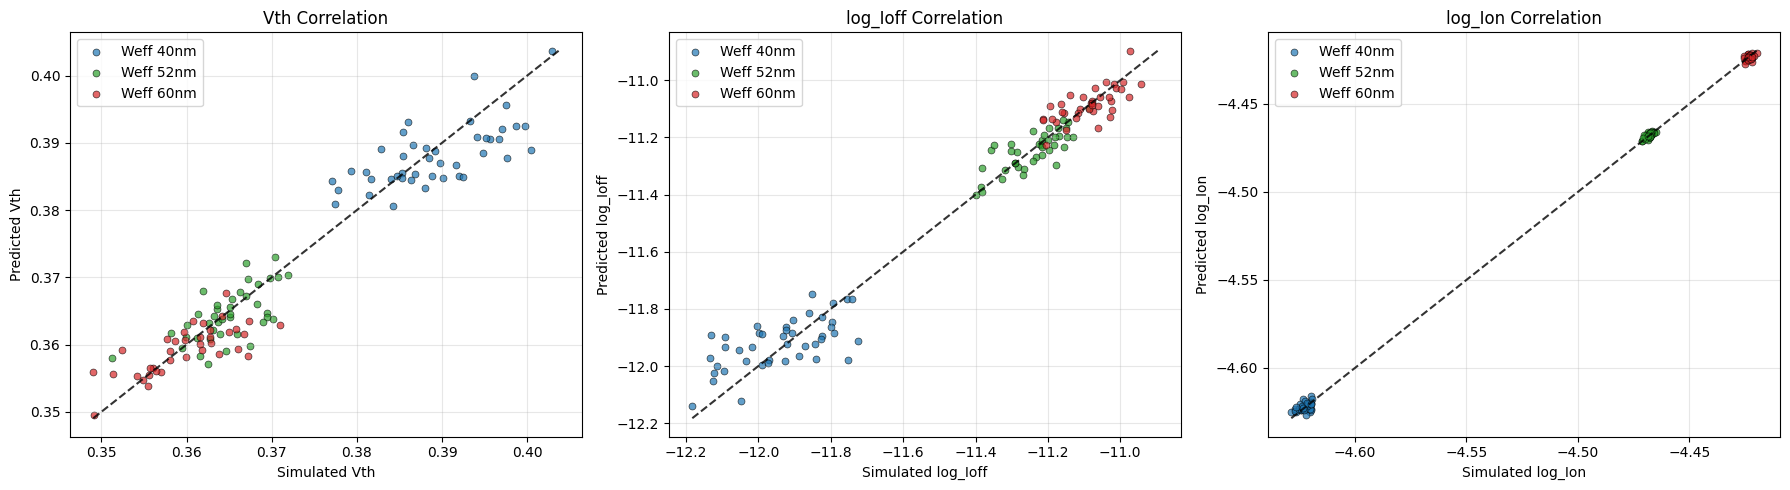

In [ ]:
# Make predictions
y_pred_scaled = model.predict([X_weff_test, X_seed_test])
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = y[test_idx] # Original physical values

targets = ['Vth', 'log_Ioff', 'log_Ion']
weff_vals = X_weff[test_idx].flatten()
colors = {40: '#1f77b4', 52: '#2ca02c', 60: '#d62728'}

plt.figure(figsize=(18, 5))

for i, target in enumerate(targets):
    plt.subplot(1, 3, i+1)

    for w in [40, 52, 60]:
        mask = (weff_vals == w)
        plt.scatter(y_true[mask, i], y_pred[mask, i],
                    color=colors[w], alpha=0.7, label=f'Weff {w}nm', s=25, edgecolors='k', linewidth=0.5)

    # Diagonal line
    all_vals = np.concatenate([y_true[:, i], y_pred[:, i]])
    plt.plot([all_vals.min(), all_vals.max()], [all_vals.min(), all_vals.max()], 'k--', alpha=0.8)

    plt.xlabel(f'Simulated {target}')
    plt.ylabel(f'Predicted {target}')
    plt.title(f'{target} Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()